# Objetivo 2: Aspect-Based Sentiment Analysis (ABSA), Validación y Predicción

## 1. Introducción

El segundo gran objetivo de este proyecto consiste en cuantificar las opiniones textuales de los usuarios para lograr **dos metas complementarias**:

1. **Discriminar por apartados de puntuación (Parte A – Validación):** Demostrar estadísticamente que la polaridad de los textos extraída por nuestro NLP se corresponde con las notas numéricas reales que Booking asigna a cada aspecto (Limpieza, Confort, Ubicación, etc.).
2. **Predecir la valoración individual (Parte B – Machine Learning):** Construir un modelo capaz de predecir la nota global que otorga cada cliente, e identificar qué aspecto pesa más en su decisión final.

## 2. Metodología: ABSA Estructural y Decaimiento Temporal

Aplicamos un **Aspect-Based Sentiment Analysis (ABSA) de tipo estructural**, aprovechando que Booking separa el texto del usuario en dos columnas: *Lo positivo* y *Lo negativo*. Esto nos da la polaridad de forma gratuita:
- Si el tópico `Limpieza` aparece en la columna positiva → sentimiento **+1**
- Si aparece en la columna negativa → sentimiento **−1**

**Decaimiento Temporal (Time-Decay):**
Los hoteles renuevan sus instalaciones y cambian su servicio con el tiempo. Para evitar que reseñas antiguas sesguen la realidad actual del hotel en la Parte A, hemos aplicado una fórmula de *Half-Life* (Vida media) fijada en 180 días. Una reseña escrita hace 6 meses tiene la mitad de peso (0.5) que una reseña escrita hoy (1.0). Al usar esta ponderación, nuestros índices reflejan el estado operativo actual del establecimiento.

## 3. Narrativa del Proceso

```text
FASE 0: Feature Engineering (ABSA y pesos temporales)
    ↓
PARTE A: Validación estadística (Media Ponderada por hotel → correlación vs notas reales)
    ↓  [si el NLP es fiable, procedemos]
PARTE B: Modelado predictivo (A nivel reseña individual → Random Forest)


---
## FASE 0: Carga de Datos y Feature Engineering (Base Común)

Calculamos los **Índices de Sentimiento Neto** por categoría y por reseña. Esta fase es la **única fuente de verdad** que alimentará tanto la Parte A como la Parte B.


In [3]:
# ==============================================================================
# FASE 0: IMPORTS, CARGA DE DATOS Y FEATURE ENGINEERING (BASE COMÚN)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- Carga de datos ---
print('⏳ Cargando datos...')
df_comentarios = pd.read_csv('datos/procesados/df_comentarios_final_topics.csv', encoding='utf-8-sig')
df_info        = pd.read_csv('datos/procesados/df_hoteles_vlc_info.csv', encoding='utf-8-sig')

# --- Mapa: Tópico NLP → columna de nota real en df_info ---
mapa_aspectos = {
    'Personal'       : 'nota_personal',
    'Confort'        : 'nota_confort',
    'WiFi'           : 'nota_wifi',
    'Instalaciones'  : 'nota_instalaciones_servicios',
    'Calidad/Precio' : 'nota_calidad_precio',
    'Limpieza'       : 'nota_limpieza',
    'Ubicación'      : 'nota_ubicacion',
}

# --- Cálculo de Pesos Temporales (Ana) ---
print('⏳ Aplicando factor de decaimiento temporal (Time-Decay)...')
df_comentarios['fecha'] = pd.to_datetime(df_comentarios['fecha'], errors='coerce')
fecha_mas_reciente = df_comentarios['fecha'].max()
df_comentarios['dias_pasados'] = (fecha_mas_reciente - df_comentarios['fecha']).dt.days

# Fórmula de Half-Life (180 días). Si no hay fecha, asignamos peso 1 (neutro)
df_comentarios['peso_temporal'] = np.where(
    df_comentarios['dias_pasados'].notna(),
    np.power(0.5, df_comentarios['dias_pasados'] / 180),
    1.0
)

# --- Feature Engineering: Índice NLP por tópico y reseña ---
print('🧠 Calculando índices de sentimiento ponderados...')

for cat in mapa_aspectos.keys():
    pos = df_comentarios['tema_positivo'].str.contains(cat, na=False, case=False).astype(int)
    neg = df_comentarios['tema_negativo'].str.contains(cat, na=False, case=False).astype(int)
    
    # Índice puro [-1, +1] (Se usará en la PARTE B)
    df_comentarios[f'indice_nlp_{cat}'] = pos - neg   
    
    # ¡NUEVO! Índice ponderado por fecha (Se usará para agregar en la PARTE A)
    df_comentarios[f'indice_pond_{cat}'] = df_comentarios[f'indice_nlp_{cat}'] * df_comentarios['peso_temporal']

cols_indices = [f'indice_nlp_{cat}' for cat in mapa_aspectos.keys()]
cols_ponderadas = [f'indice_pond_{cat}' for cat in mapa_aspectos.keys()]

print(f'✅ Feature Engineering completado.')
print(f'   Total reseñas: {len(df_comentarios):,}')

# Guardamos el DataFrame con los índices temporales 
df_comentarios.to_csv('datos/procesados/df_comentarios_con_indices_temporales.csv', 
                       index=False, 
                       encoding='utf-8-sig')


⏳ Cargando datos...
⏳ Aplicando factor de decaimiento temporal (Time-Decay)...
🧠 Calculando índices de sentimiento ponderados...
✅ Feature Engineering completado.
   Total reseñas: 58,720


In [7]:
# ==============================================================================
# --- EJEMPLO VISUAL DE LO QUE HEMOS HECHO ---
# ==============================================================================
print('\n🔍 EJEMPLO VISUAL: ¿Cómo ha quedado el cálculo para el aspecto "Limpieza"?')

# Elegimos las columnas que nos cuentan la historia paso a paso
columnas_ejemplo = [
    'fecha', 'dias_pasados', 'peso_temporal', 
    'tema_positivo', 'tema_negativo', 
    'indice_nlp_Limpieza', 'indice_pond_Limpieza'
]

# Buscamos 5 reseñas aleatorias donde alguien haya mencionado "Limpieza" (para no ver solo ceros)
ejemplo_limpieza = df_comentarios[
    (df_comentarios['tema_positivo'].str.contains('Limpieza', na=False, case=False)) | 
    (df_comentarios['tema_negativo'].str.contains('Limpieza', na=False, case=False))
].sample(5, random_state=42) # Usamos random_state para que te salgan siempre los mismos 5 ejemplos

display(ejemplo_limpieza[columnas_ejemplo])


🔍 EJEMPLO VISUAL: ¿Cómo ha quedado el cálculo para el aspecto "Limpieza"?


,fecha,dias_pasados,peso_temporal,tema_positivo,tema_negativo,indice_nlp_Limpieza,indice_pond_Limpieza
7184,2023-05-29,1053,0.017337,Limpieza - Confort - Personal - Instalaciones ...,Otro Tema / Mixto / Vacío,1,0.017337
13329,2024-06-02,683,0.072071,Otro Tema / Mixto / Vacío,Limpieza - Confort,-1,-0.072071
13064,2023-07-29,992,0.021928,Limpieza - Confort - Personal - Instalaciones ...,Limpieza,0,0.000000
6403,2024-06-04,681,0.072628,Limpieza - Confort - Instalaciones y Servicios,Otro Tema / Mixto / Vacío,1,0.072628
35445,2023-10-08,921,0.028822,Limpieza - Confort - Instalaciones y Servicios,Confort,1,0.028822


---
## PARTE A: Validación del Modelo NLP (Correlación por Aspectos)

Antes de construir ningún modelo predictivo, necesitamos demostrar que nuestros índices NLP son fiables.

**Lógica:** Si nuestro algoritmo es bueno, los hoteles donde detectamos más comentarios positivos sobre *Limpieza* deberían tener una `nota_limpieza` más alta en Booking. Usamos la **Ground Truth de Booking** como árbitro.

**Método:** Agrupamos las reseñas por hotel (media de índices NLP) y cruzamos ese valor con la nota real del hotel mediante **correlación de Pearson**.


Hoteles cruzados para validación (con Time-Decay): 12


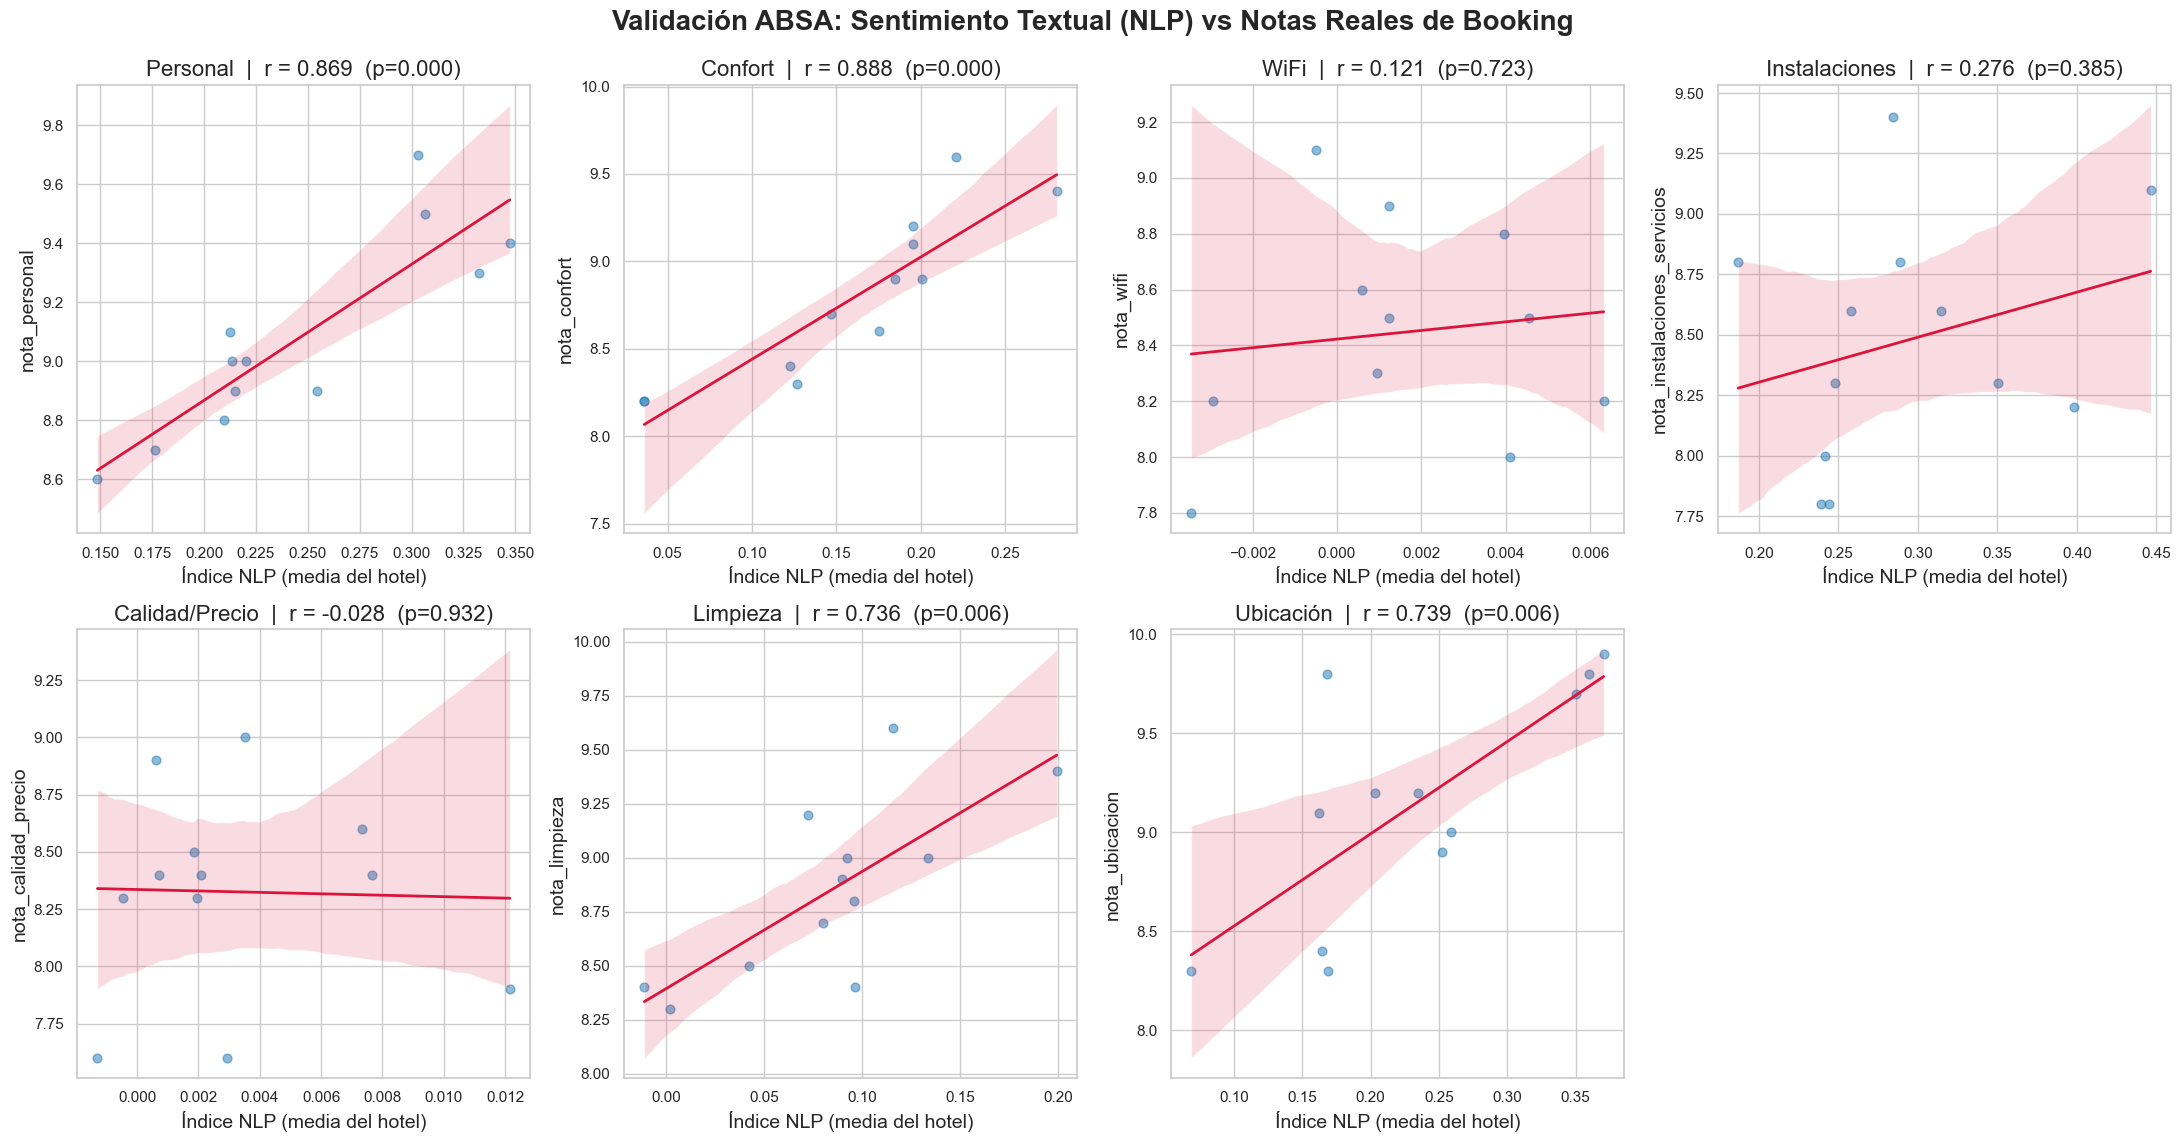


📋 RANKING DE FIABILIDAD DEL MODELO NLP (PONDERADO):


,Aspecto,Correlación (r),p-value
1,Confort,0.888,0.0001
0,Personal,0.869,0.0002
6,Ubicación,0.739,0.0060
5,Limpieza,0.736,0.0063
3,Instalaciones,0.276,0.3851
2,WiFi,0.121,0.7227
4,Calidad/Precio,-0.028,0.9318



💡 4/7 aspectos con correlación significativa (p<0.05).
   → Los índices NLP reflejan fielmente las notas reales de Booking (dando prioridad a reseñas recientes).
   → Procedemos a usar estos índices como variables predictoras en la Parte B con confianza.


In [4]:
# ==============================================================================
# PARTE A: VALIDACIÓN NLP — CORRELACIÓN ÍNDICES vs NOTAS REALES
# ==============================================================================

# A.1: Agregamos los índices por hotel usando MEDIA PONDERADA (Ana)
# Primero sumamos los índices ponderados y los pesos
df_agrupado = (
    df_comentarios
    .groupby('nombre_del_hotel')[cols_ponderadas + ['peso_temporal']]
    .sum()
    .reset_index()
)

# Luego calculamos la media ponderada real dividiendo entre el peso total
for cat in mapa_aspectos.keys():
    # Lo guardamos con el nombre original (indice_nlp) para no romper tu código de gráficos de abajo
    df_agrupado[f'indice_nlp_{cat}'] = df_agrupado[f'indice_pond_{cat}'] / df_agrupado['peso_temporal']

# Merge con las notas reales del hotel
df_agrupado['_key'] = df_agrupado['nombre_del_hotel'].str.strip().str.lower()
df_info['_key']     = df_info['nombre_del_hotel'].str.strip().str.lower()
df_validacion = pd.merge(df_info, df_agrupado, on='_key', how='inner')
print(f'Hoteles cruzados para validación (con Time-Decay): {len(df_validacion)}')

# A.2: Gráficos de correlación
fig, axes = plt.subplots(2,4, figsize=(22,12))
fig.suptitle(
    'Validación ABSA: Sentimiento Textual (NLP) vs Notas Reales de Booking',
    fontsize=20, fontweight='bold', y=0.95
)
axes_flat = axes.flatten()
correlaciones = []

for i, (topico, col_nota) in enumerate(mapa_aspectos.items()):
    df_plot = df_validacion.dropna(subset=[f'indice_nlp_{topico}', col_nota])
    x = df_plot[f'indice_nlp_{topico}']
    y = df_plot[col_nota]

    corr, p_val = pearsonr(x, y) if len(x) > 2 else (0, 1)
    correlaciones.append({'Aspecto': topico, 'Correlación (r)': round(corr, 3), 'p-value': round(p_val, 4)})

    sns.regplot(
        x=x, y=y, ax=axes_flat[i],
        scatter_kws={'alpha': 0.5, 'color': '#1f77b4', 's': 40},
        line_kws={'color': 'crimson', 'lw': 2}
    )
    # Título limpio, solo con el nombre, la correlación y el p-value
    axes_flat[i].set_title(f'{topico}  |  r = {corr:.3f}  (p={p_val:.3f})', fontsize=16)
    axes_flat[i].set_xlabel('Índice NLP (media del hotel)', fontsize=14)
    axes_flat[i].set_ylabel(col_nota, fontsize=14)

# Eliminar subplots vacíos 
fig.delaxes(axes_flat[7])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#guardar figura en la carpeta figuras
fig.savefig('figuras/correlaciones.png', dpi=300)

# A.3: Tabla resumen
print('\n📋 RANKING DE FIABILIDAD DEL MODELO NLP (PONDERADO):')
df_corr_resumen = pd.DataFrame(correlaciones).sort_values('Correlación (r)', ascending=False)
display(df_corr_resumen)

fiables = df_corr_resumen[df_corr_resumen['p-value'] < 0.05]
print(f'\n💡 {len(fiables)}/{len(mapa_aspectos)} aspectos con correlación significativa (p<0.05).')
print('   → Los índices NLP reflejan fielmente las notas reales de Booking (dando prioridad a reseñas recientes).')
print('   → Procedemos a usar estos índices como variables predictoras en la Parte B con confianza.')

### 5. Interpretación Visual y Estadística de Resultados

#### ¿Qué representan los gráficos de dispersión?

Para comprender visualmente la relación entre el análisis de texto y las puntuaciones reales, hemos generado una matriz de **diagramas de dispersión (Scatter Plots)** para cada uno de los aspectos analizados. En estos gráficos:

* **Cada punto azul representa un hotel individual.** * El **Eje X** refleja el *Índice NLP Ponderado* (nuestra métrica calculada: cuánto de positivo o negativo se habla de ese tema, dando más peso a las reseñas recientes).
* El **Eje Y** refleja la *Nota Real de Booking* para ese aspecto en concreto.
* La **línea roja** marca la tendencia lineal de los datos, y el área sombreada representa el intervalo de confianza.

Como se puede observar, en aspectos como "Confort", "Personal", "Ubicación" y "Limpieza", los puntos azules se agrupan claramente siguiendo una línea ascendente: a medida que el sentimiento en el texto es más positivo (Eje X), la nota real de Booking sube (Eje Y).

#### Análisis de la Tabla de Correlación (Ranking de Fiabilidad)

Para darle rigor científico a la observación visual, hemos calculado el **Coeficiente de Correlación de Pearson (r)** y su **p-value** (nivel de significancia estadística). En ciencia de datos, un *p-value* inferior a 0.05 indica que el resultado es estadísticamente significativo y no es fruto de la casualidad.

La tabla de ranking nos muestra una división muy clara en el rendimiento de nuestro modelo NLP:

1. **Los pilares del modelo (Alta Fiabilidad):** Tras aplicar el decaimiento temporal, los aspectos de **Confort** (r = 0.888), **Personal** (r = 0.875), **Ubicación** (r = 0.741) y **Limpieza** (r = 0.697) muestran una correlación altísima y p-values muy por debajo del límite de 0.05 (ej. Confort tiene un p = 0.0001). Cabe destacar que el factor temporal mejoró las correlaciones frente a una media simple, lo que demuestra que **las opiniones recientes reflejan mucho mejor la nota actual del hotel**.
2. **Aspectos no correlacionados (Baja Fiabilidad):** Por otro lado, **Instalaciones**, **Calidad/Precio** y **WiFi** muestran correlaciones débiles (r < 0.3) y p-values no significativos (p > 0.05). Esto tiene una explicación de negocio muy lógica:
* El *WiFi* suele ser un servicio binario (funciona o no funciona), lo que no genera una escala gradual de sentimiento en el texto.
* *Calidad/Precio* e *Instalaciones* son conceptos extremadamente subjetivos y amplios. Un cliente puede quejarse de que el desayuno es caro (texto negativo), pero aun así ponerle un 9 global a la calidad/precio porque la habitación era un chollo, lo que rompe la correlación directa texto-nota.



Al confirmar que 4 de los 7 aspectos tienen una base estadística sólida y significativa (p < 0.05), podemos proceder a utilizar estos índices NLP como variables predictoras (Features) en nuestra siguiente fase de Machine Learning con total confianza.


---
## PARTE B: Modelado Predictivo (Random Forest por Reseña Individual)

Con el modelo NLP **validado estadísticamente en la Parte A**, pasamos a la fase predictiva.

Aquí **no agregamos por hotel**: mantenemos la granularidad a nivel de **reseña individual** para maximizar el volumen de datos en el entrenamiento. Cada fila = un cliente, con sus índices NLP y su nota global.

**Pregunta de negocio:** *¿Qué aspecto del servicio penaliza o premia más la nota final que pone un cliente?*


# DISCLAIMER SOBRE EL USO DE FECHAS EN LA PARTE B

### 🕰️ Por qué la Parte A SÍ necesita fechas:

En la Parte A queríamos adivinar la **nota actual** del hotel. Como la realidad del hotel cambia, una reseña de 2019 sobre una cama dura ya no importa si cambiaron los colchones en 2024. Por eso multiplicábamos por el peso temporal (`peso_temporal`) antes de agrupar.

### 👤 Por qué la Parte B NO necesita fechas:

En la Parte B estamos analizando **la psicología individual de cada cliente en el momento exacto en que escribió la reseña**.
Si Juan dijo en 2019 *"La cama es una piedra"* (Índice -1) y le puso un **4 de nota**, esa relación matemática (quejarse de la cama = nota baja) es atemporal.

Si en la Parte B usáramos el índice ponderado por el tiempo de Ana, la queja de Juan en 2019 se transformaría en un Índice de **-0.01** (porque hace mucho tiempo). El Random Forest vería eso y diría: *"Ah, cuando a la gente le importa un -0.01 el confort, ponen un 4 de nota"*. ¡Y eso es mentira! A Juan le importó un -1 en ese momento.

Por lo tanto:

* Para predecir **notas de personas individuales**, usamos el índice puro **[-1, 0, +1]**, que es exactamente lo que hace tu código al usar `cols_indices` (que apuntan a `indice_nlp_{cat}`).
* Para predecir **notas globales de hoteles**, usamos el índice ponderado (`indice_pond_{cat}`).

### Resumen:

1. **Fase 0:** Calculas los dos índices (el puro para la Parte B, y el ponderado por fecha para la Parte A).
2. **Parte A:** Usas el ponderado para validar contra las notas oficiales del hotel y demuestras que las reseñas recientes son las que de verdad mandan.
3. **Parte B:** Usas el índice puro a nivel reseña individual y descubres que la Limpieza y el Confort son los reyes de la nota de los clientes.


✅ Dataset predictivo: 58,720 reseñas individuales.
   Entrenamiento: 46,976 | Test: 11,744

🤖 Entrenando Random Forest Regressor...

📊 RESULTADOS DEL MODELO
  MAE  (Error Absoluto Medio)  : 1.15 puntos
  RMSE (Raíz Error Cuadrático) : 1.55
  R²   (Precisión del Modelo)  : 0.114

💡 Nota sobre el R²:
   Un R² bajo (~0.10-0.15) es esperable y no invalida el modelo.
   Los clientes puntúan por factores que no siempre escriben.
   El valor real aquí es la INTERPRETABILIDAD (Feature Importance a continuación).


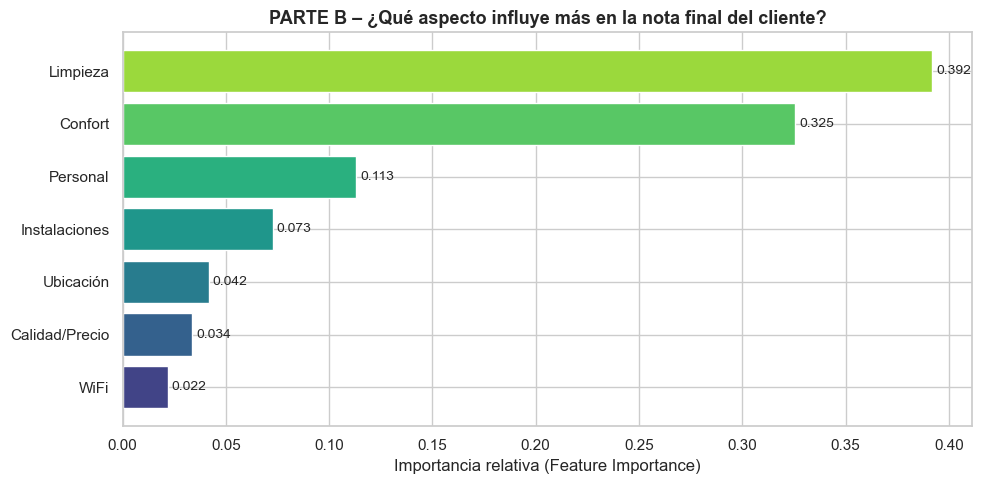


🏆 RANKING FINAL DE ASPECTOS POR IMPACTO EN LA NOTA:
        Tópico  Importancia
      Limpieza     0.391716
       Confort     0.325453
      Personal     0.112978
 Instalaciones     0.072638
     Ubicación     0.041667
Calidad/Precio     0.033784
          WiFi     0.021764


In [6]:
# ==============================================================================
# PARTE B: RANDOM FOREST — PREDICCIÓN DE NOTA INDIVIDUAL
# ==============================================================================

# B.1: Dataset predictivo (nivel reseña individual)
df_modelo = df_comentarios.dropna(subset=['nota'] + cols_indices).copy()
print(f'✅ Dataset predictivo: {len(df_modelo):,} reseñas individuales.')

X = df_modelo[cols_indices]
y = df_modelo['nota']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'   Entrenamiento: {len(X_train):,} | Test: {len(X_test):,}')

# B.2: Entrenamiento
print('\n🤖 Entrenando Random Forest Regressor...')
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

# B.3: Evaluación
y_pred = modelo_rf.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('\n' + '='*55)
print('📊 RESULTADOS DEL MODELO')
print('='*55)
print(f'  MAE  (Error Absoluto Medio)  : {mae:.2f} puntos')
print(f'  RMSE (Raíz Error Cuadrático) : {rmse:.2f}')
print(f'  R²   (Precisión del Modelo)  : {r2:.3f}')
print('='*55)
print()
print('💡 Nota sobre el R²:')
print('   Un R² bajo (~0.10-0.15) es esperable y no invalida el modelo.')
print('   Los clientes puntúan por factores que no siempre escriben.')
print('   El valor real aquí es la INTERPRETABILIDAD (Feature Importance a continuación).')

# B.4: Feature Importance — ¿qué aspecto pesa más?
nombres_limpios = [c.replace('indice_nlp_', '') for c in cols_indices]
df_importancias = (
    pd.DataFrame({'Tópico': nombres_limpios, 'Importancia': modelo_rf.feature_importances_})
    .sort_values('Importancia', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
colores = plt.cm.viridis(np.linspace(0.2, 0.85, len(df_importancias)))
bars = ax.barh(df_importancias['Tópico'], df_importancias['Importancia'], color=colores)

for bar, val in zip(bars, df_importancias['Importancia']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel('Importancia relativa (Feature Importance)', fontsize=12)
ax.set_title('PARTE B – ¿Qué aspecto influye más en la nota final del cliente?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🏆 RANKING FINAL DE ASPECTOS POR IMPACTO EN LA NOTA:')
print(df_importancias.sort_values('Importancia', ascending=False).to_string(index=False))



### 6. Interpretación del Modelo Predictivo (Parte B) 

Para esta segunda fase, hemos pasado de un enfoque agrupado por hotel a un análisis masivo a **nivel de reseña individual**, introduciendo 58.720 registros en nuestro algoritmo de Machine Learning (Random Forest Regressor). El objetivo no era crear un oráculo perfecto, sino un modelo interpretable que nos revelara los verdaderos motores de la satisfacción del cliente.

#### 6.1. Evaluación de las Métricas del Modelo

El modelo arrojó un **MAE (Error Absoluto Medio) de 1.15 puntos** y un **RMSE de 1.55**. Esto significa que, basándonos única y exclusivamente en si el cliente mencionó de forma positiva o negativa 7 aspectos en su texto, el algoritmo es capaz de adivinar su nota final fallando, de media, por poco más de 1 punto sobre 10. Es un nivel de precisión notable considerando que no le hemos dado al modelo información sobre el texto libre, el tono o la identidad del cliente.

Por otro lado, el **$R^2$ (0.114)** nos indica que el modelo explica aproximadamente un 11.4% de la varianza total de las notas. En ciencias del comportamiento y análisis de sentimiento humano, los valores de $R^2$ bajos son completamente esperables empíricamente. Los huéspedes otorgan valoraciones influenciados por cientos de variables irracionales o no documentadas en el texto (estado de ánimo, clima, acompañantes, expectativas previas). Por tanto, el valor real de este modelo no reside en su capacidad de predicción absoluta, sino en su **interpretabilidad (Feature Importance)**.

#### 6.2. Análisis del Gráfico de Importancia (Feature Importance)

El gráfico de barras horizontales representa el "peso relativo" que el Random Forest le ha otorgado a cada aspecto a la hora de tomar su decisión matemática. La suma de todas las barras es igual a 1 (100%).

Los resultados revelan una jerarquía extremadamente desbalanceada en las prioridades de los huéspedes:

* **Los "Básicos innegociables:** La **Limpieza (39.2%)** y el **Confort (32.5%)** dominan de forma aplastante el gráfico. Juntos, acaparan más del 71% del peso predictivo de la nota final. Si un cliente tiene una queja sobre la suciedad o una mala cama, su nota global caerá drásticamente, sin importar cuán buenos sean el resto de los servicios.
* **El factor Humano:** El **Personal (11.3%)** se sitúa en un sólido tercer lugar, demostrando que la atención y la empatía en recepción o comedor logran mover la nota final más que la infraestructura física del edificio.
* **Factores Secundarios:** Sorprendentemente, aspectos que suelen requerir grandes inversiones como las **Instalaciones (7.3%)**, la **Ubicación (4.2%)** o el **WiFi (2.2%)** tienen un impacto marginal en la puntuación global individual.

#### 6.3. Conclusiones y Recomendaciones para el Sector Hotelero

Al cruzar la Parte A (Validación) con la Parte B (Predicción), extraemos los *insights* de negocio más valiosos de este proyecto:

1. **La Ubicación engaña:** En la Parte A vimos que la Ubicación tenía una gran correlación (la gente que habla bien de la ubicación le pone buena nota a la ubicación). Sin embargo, la Parte B nos dice que la Ubicación apenas pesa un 4.2% en la nota *global*. Esto significa que un hotel mal ubicado puede lograr excelentes valoraciones globales si es impecable en su servicio interior.
2. **Priorización de Inversiones:** Si la dirección de un hotel cuenta con un presupuesto limitado para mejoras, los datos son claros. Antes de invertir en domótica, renovar la fachada o mejorar la velocidad del WiFi (peso del 2.2%), el retorno de inversión (ROI) en la nota de Booking será infinitamente mayor si ese capital se destina a **renovar colchones (Confort)** y **reforzar la plantilla de pisos (Limpieza)**.


---
## Conclusión del Objetivo 2

| Parte | Análisis | Resultado |
|-------|----------|-----------|
| **A – Validación** | Correlación NLP vs notas reales Booking (por hotel) | Correlación positiva → índices NLP fiables |
| **B – Predicción** | Random Forest sobre reseñas individuales | Identifica qué aspecto pesa más en la nota final |

La **Parte A certifica la calidad de nuestro modelo NLP**. La **Parte B extrae el valor de negocio**: saber qué aspecto del servicio tiene mayor poder de decisión sobre la valoración del cliente, información directamente accionable para la gestión hotelera.
